# Data exploration: Hugging Face Connections dataset

Graph inspections of the dataset using train/test splits from `data_loader`. Run cells in order.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path

from data_loader import get_train_test_split

FIGURES_DIR = Path("results") / "figures"
SAVE_FIGURES = False

In [7]:
ds_train, ds_test = get_train_test_split()
LLAMA_CUTOFF_WINDOW = (datetime(2023, 12, 5), datetime(2023, 12, 25))
train_dates = [row.get("date") for row in ds_train]
test_dates = [row.get("date") for row in ds_test]
train_difficulties = ds_train["difficulty"]
test_difficulties = ds_test["difficulty"]


def parse_date(s):
    if s is None:
        return None
    if hasattr(s, "timestamp"):
        return s
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%Y-%m-%dT%H:%M:%S"):
        try:
            return datetime.strptime(str(s).strip()[:19], fmt)
        except (ValueError, TypeError):
            continue
    return None


train_parsed = [parse_date(d) for d in train_dates]
test_parsed = [parse_date(d) for d in test_dates]
train_ts = [d for d in train_parsed if d is not None]
test_ts = [d for d in test_parsed if d is not None]

## Splits by puzzle timestamp

Histogram of puzzle count by date (train vs test).

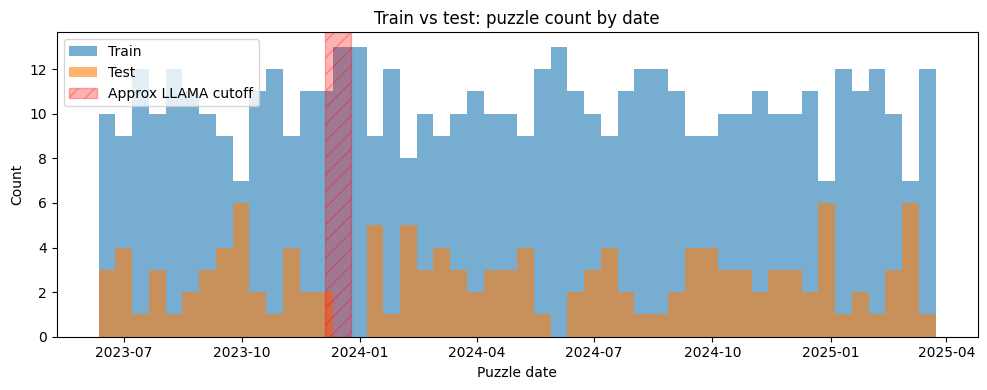

In [8]:


fig, ax = plt.subplots(figsize=(10, 4))

if train_ts or test_ts:
    all_ts = train_ts + test_ts
    n_bins = min(50, max(1, len(set(all_ts))))
    bins = np.linspace(min(all_ts).timestamp(), max(all_ts).timestamp(), n_bins + 1)
    bins_dt = [datetime.fromtimestamp(t) for t in bins]

    ax.hist(train_ts, bins=bins_dt, alpha=0.6, label="Train", color="C0", density=False)
    ax.hist(test_ts, bins=bins_dt, alpha=0.6, label="Test", color="C1", density=False)
    ax.axvspan(LLAMA_CUTOFF_WINDOW[0], LLAMA_CUTOFF_WINDOW[1], alpha=0.3, color="red", hatch='//', label="Approx LLAMA cutoff")
    ax.set_xlabel("Puzzle date")
    ax.set_ylabel("Count")
    ax.set_title("Train vs test: puzzle count by date")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No date column or parseable dates", ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES_DIR / "explore_splits_by_timestamp.png", dpi=150, bbox_inches="tight")
plt.show()

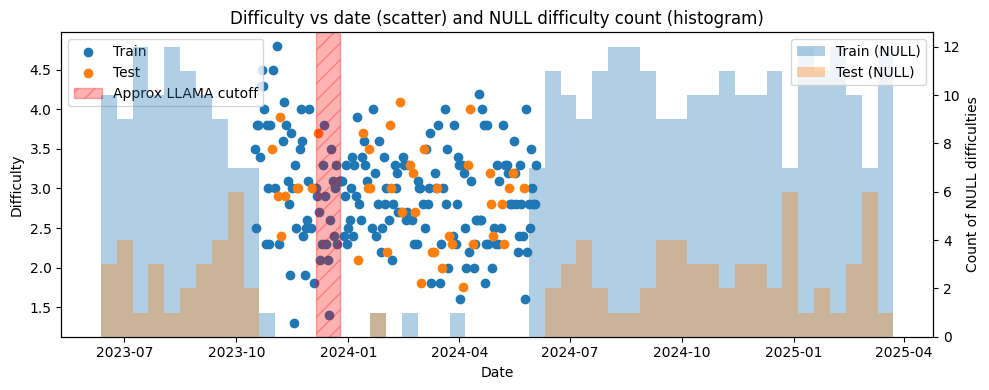

In [9]:


train_nonnull = [(train_parsed[i], diff) for i, diff in enumerate(train_difficulties) if diff is not None and train_parsed[i] is not None]
test_nonnull = [(test_parsed[i], diff) for i, diff in enumerate(test_difficulties) if diff is not None and test_parsed[i] is not None]
train_dates_nn, train_diffs_nn = (list(zip(*train_nonnull)) if train_nonnull else ([], []))
test_dates_nn, test_diffs_nn = (list(zip(*test_nonnull)) if test_nonnull else ([], []))

train_ts_null = [train_parsed[i] for i in range(len(train_parsed)) if train_difficulties[i] is None and train_parsed[i] is not None]
test_ts_null = [test_parsed[i] for i in range(len(test_parsed)) if test_difficulties[i] is None and test_parsed[i] is not None]

fig, ax = plt.subplots(figsize=(10, 4))
if train_dates_nn:
    ax.scatter(train_dates_nn, train_diffs_nn, label='Train', color='C0')
if test_dates_nn:
    ax.scatter(test_dates_nn, test_diffs_nn, label='Test', color='C1')
ax.axvspan(LLAMA_CUTOFF_WINDOW[0], LLAMA_CUTOFF_WINDOW[1], alpha=0.3, color="red", hatch='//', label="Approx LLAMA cutoff")
ax.set_xlabel('Date')
ax.set_ylabel('Difficulty')
ax.set_title('Difficulty vs date (scatter) and NULL difficulty count (histogram)')

ax2 = ax.twinx()
if train_ts_null or test_ts_null:
    all_ts_null = train_ts_null + test_ts_null
    n_bins = min(50, max(1, len(set(all_ts_null))))
    bins = np.linspace(min(all_ts_null).timestamp(), max(all_ts_null).timestamp(), n_bins + 1)
    bins_dt = [datetime.fromtimestamp(t) for t in bins]
    if train_ts_null:
        ax2.hist(train_ts_null, bins=bins_dt, alpha=0.35, label='Train (NULL)', color='C0', density=False, histtype='stepfilled')
    if test_ts_null:
        ax2.hist(test_ts_null, bins=bins_dt, alpha=0.35, label='Test (NULL)', color='C1', density=False, histtype='stepfilled')
ax2.set_ylabel('Count of NULL difficulties')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES_DIR / "explore_difficulty_and_null_by_date.png", dpi=150, bbox_inches="tight")
plt.show()


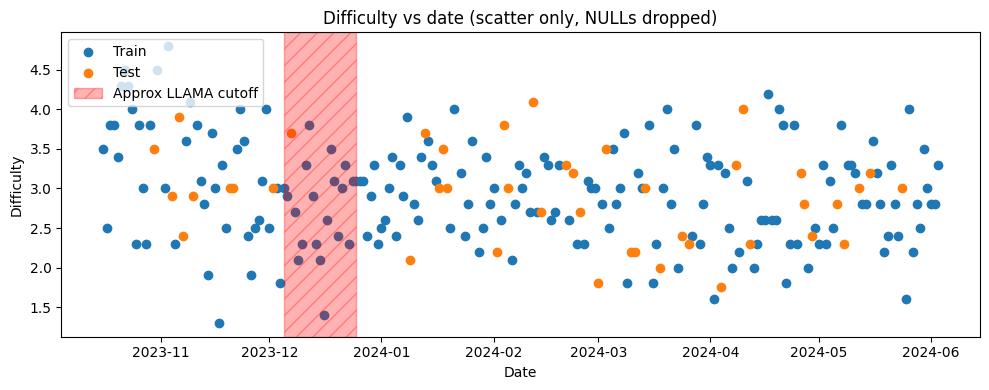

In [10]:
# Difficulty vs date (scatter only, NULL difficulties dropped)
train_nonnull = [(train_parsed[i], diff) for i, diff in enumerate(train_difficulties) if diff is not None and train_parsed[i] is not None]
test_nonnull = [(test_parsed[i], diff) for i, diff in enumerate(test_difficulties) if diff is not None and test_parsed[i] is not None]
train_dates_nn, train_diffs_nn = (list(zip(*train_nonnull)) if train_nonnull else ([], []))
test_dates_nn, test_diffs_nn = (list(zip(*test_nonnull)) if test_nonnull else ([], []))

fig, ax = plt.subplots(figsize=(10, 4))
if train_dates_nn:
    ax.scatter(train_dates_nn, train_diffs_nn, label='Train', color='C0')
if test_dates_nn:
    ax.scatter(test_dates_nn, test_diffs_nn, label='Test', color='C1')
ax.axvspan(LLAMA_CUTOFF_WINDOW[0], LLAMA_CUTOFF_WINDOW[1], alpha=0.3, color="red", hatch='//', label="Approx LLAMA cutoff")
ax.set_xlabel('Date')
ax.set_ylabel('Difficulty')
ax.set_title('Difficulty vs date (scatter only, NULLs dropped)')
ax.legend(loc='upper left')
plt.tight_layout()
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES_DIR / "explore_difficulty_by_date_no_nulls.png", dpi=150, bbox_inches="tight")
plt.show()